In [2]:
import numpy as np
import matplotlib.pyplot as plt
import src.routines.tomo_fusion.tools.plotting_fcts as tomo_plots

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
params = np.load('../tcv_geometry/bolo_LoS_params.npy')

In [5]:
tcv_shape_coords = np.load("../tcv_geometry/tcv_shape_coords.npy")

(-10.5, 131.0)

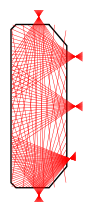

In [7]:
# plot ground truth, superposing the sxr LoS
tomo_plots.plot_profile(np.ones((120,41)), levels=12, figsize=(2,2.5), tcv_plot_clip=True, ax=None, cmap="gray", vmax=1, vmin=0)
r_vert = np.linspace(0.6, 40.4, 8000)
r_horiz = np.linspace(0.6, 52.4, 4000)
r_div = np.linspace(0.6, 47.4, 4000)
center = np.array([120, 41], dtype=int) / 2
Lr, Lz = 0.511, 1.5
h = Lz / 120
for i in range(params.shape[0]):
    if np.isclose(np.tan(params[i, 1]), 0, atol=1e-6):
        plt.vlines(center[1] + params[i, 0], 0, Lz, "r", linewidth=0.3)
    else:
        p = params[i, 0]
        theta = params[i, 1]
        y = center[0] + p / h / np.sin(theta) - (r_vert - center[1]) / np.tan(theta)
        if i<20:
            y = center[0] + p / h / np.sin(theta) - (r_vert - center[1]) / np.tan(theta)
            plt.plot(r_vert[(y>0.4) & (y<135)], y[(y>0.4) & (y<135)], "r", linewidth=0.3)
        elif i<60:
            y = center[0] + p / h / np.sin(theta) - (r_horiz - center[1]) / np.tan(theta)
            plt.plot(r_horiz[(y>0.4) & (y<119.6)], y[(y>0.4) & (y<119.6)], "r", linewidth=0.3)
        elif i<100:
            y = center[0] + p / h / np.sin(theta) - (r_div - center[1]) / np.tan(theta)
            plt.plot(r_div[(y>0.4) & (y<119.6)], y[(y>0.4) & (y<119.6)], "r", linewidth=0.3)
        elif i<120:
            y = center[0] + p / h / np.sin(theta) - (r_vert - center[1]) / np.tan(theta)
            plt.plot(r_vert[(y>-15) & (y<119.6)], y[(y>-15) & (y<119.6)], "r", linewidth=0.3)
        else:
            plt.plot(r_vert, y, "r", linewidth=0.4)
# plt.xlim([-0.75, 41.75])
# plt.ylim([-0.75, round(Lz / h)+0.75])
plt.xlim([-0.75, 52.75])
plt.ylim([-10.5, 131])

#plt.savefig('figures/bolo_LoS_configuration.eps', format='eps', bbox_inches="tight")

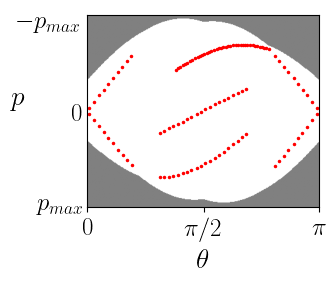

In [10]:
markersize = 3
tcv_mask_finesse = round(300)
pmin = np.min(params[:, 0])
prange = np.max(params[:, 0]) - np.min(params[:, 0])
# pmax corresponding to tcv geometry
tcv_pmax = 0.5646 + 0.25
PT_intersecting_tcv_mask = np.load('../tcv_geometry/tcv_mask_sinogram.npy')
plt.figure(figsize=(3,2.5))
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica"
})
# plot tcv mask
#plt.imshow(PT_intersecting_tcv_mask, origin="upper", aspect="auto", cmap="gray", alpha=0.5)
PT_intersecting_tcv_mask = PT_intersecting_tcv_mask.astype(float)
PT_intersecting_tcv_mask[PT_intersecting_tcv_mask<0.1] = 0.5
plt.imshow(PT_intersecting_tcv_mask, origin="upper", aspect="auto", cmap="gray", vmin=0)
# plot considered LoS configuration
scaling_factor_p = prange / (2*tcv_pmax)  # 2*pmax/(...)
scaling_factor_theta = np.max(params[:, 1]) / np.pi
ps = (params[:, 0]+np.abs(np.min(params[:, 0])))/np.max(params[:, 0]+np.abs(np.min(params[:, 0])))*(tcv_mask_finesse-1)*scaling_factor_p
# shift ps
#ps += eps / (2*pmax + 2*eps) * (tcv_mask_finesse-1)
ps += (tcv_pmax + pmin) / (2 * tcv_pmax) * (tcv_mask_finesse-1)
thetas = params[:, 1]/np.max(params[:, 1])*(tcv_mask_finesse-1)*scaling_factor_theta
for i in range(params.shape[0]):
    #a=0
    plt.plot(thetas[i], ps[i], "r", marker=".", markersize=markersize)
plt.xticks([0, tcv_mask_finesse/2, tcv_mask_finesse-1], [r'$0$', r'$\pi/2$', r'$\pi$'], fontsize=18)
plt.tick_params(axis='y',length=0)
plt.yticks([5, tcv_mask_finesse/2, tcv_mask_finesse-10], [r'$-p_{max}$', r'$0$', r'$p_{max}$'], fontsize=18)
#plt.yticks([])
plt.xlabel(r"$\theta$", fontsize=20)
plt.ylabel(r"$p$", rotation=0, fontsize=20, labelpad=0)

#plt.savefig('figures/bolo_LoS_configuration_projection_space.eps', format='eps', bbox_inches="tight")

plt.show()